# 2D Heat Equation — Overlapping Schwarz DD-ANN
## SRIP 2026 — IIT Gandhinagar | DD-ANN Phase 5

**PDE:** $\dfrac{\partial u}{\partial t} = \alpha\left(\dfrac{\partial^2 u}{\partial x^2} + \dfrac{\partial^2 u}{\partial y^2}\right)$  on $[0,1]^2 \times [0,T]$

---

## Key Differences vs 2D Poisson DD-ANN

| Aspect | 2D Poisson DD-ANN | **2D Heat Equation DD-ANN** |
|--------|------------------|-----------------------------|
| Network input | $(x,y)\to(N,2)$ | $(x,y,t)\to(N,3)$ |
| PDE residual | $-\Delta u - f$ | $u_t - \alpha\Delta u$ |
| Autodiff calls | 5 | **3** (cheaper — $u_t$ is first deriv) |
| Loss terms | 3 | **4** (adds IC term) |
| Interface | line in $y$ | **plane in $(y,t)$** |
| BC sampling | $(x_{\text{bc}},y)$ | $(x_{\text{bc}},y,t)$ — includes time |
| IC sampling | not needed | $(x,y,0)$ — $t=0$ only |
| Evaluation | 1 heatmap | **snapshots at multiple $t$** |

## Three Test Problems

| # | Exact $u(x,y,t)$ | IC $u_0$ | $\alpha$ | $T$ |
|---|-----|---|---|---|
| 1 | $e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y)$ | $\sin(\pi x)\sin(\pi y)$ | 0.1 | 1.0 |
| 2 | $e^{-5\alpha\pi^2 t}\sin(\pi x)\sin(2\pi y)$ | $\sin(\pi x)\sin(2\pi y)$ | 0.1 | 0.5 |
| 3 | $e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y) + 0.5e^{-8\alpha\pi^2 t}\sin(2\pi x)\sin(2\pi y)$ | sum | 0.1 | 0.5 |

## Section 1 — Imports & Reproducibility

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)
print(f"PyTorch {torch.__version__} | Device: {device}")

PyTorch 2.12.0+cpu | Device: cpu


## Section 2 — Network Architecture

Input now has **3 features** $(x, y, t)$ instead of 2. Everything else is identical to the 2D Poisson PINN — same 4-layer × 64-neuron Tanh MLP.

In [2]:
class PINN_Heat2D(nn.Module):
    """
    MLP for the 2D heat equation.
    Input  : (x, y, t) → shape (N, 3)
    Output : u(x,y,t)  → shape (N, 1)
    """
    def __init__(self, hidden_layers=4, hidden_size=64):
        super().__init__()
        layers = [nn.Linear(3, hidden_size), nn.Tanh()]   # 3 inputs!
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, xyt):
        return self.network(xyt)


def create_model():
    return PINN_Heat2D(hidden_layers=4, hidden_size=64).to(device)

print("PINN_Heat2D defined — input: (x,y,t), output: u(x,y,t).")

PINN_Heat2D defined — input: (x,y,t), output: u(x,y,t).


## Section 3 — Heat Equation PDE Residual

$$R(x,y,t;\theta) = \frac{\partial u_\theta}{\partial t} - \alpha\left(\frac{\partial^2 u_\theta}{\partial x^2} + \frac{\partial^2 u_\theta}{\partial y^2}\right)$$

**Autodiff strategy — only 3 calls (more efficient than Poisson):**

1. Forward pass → $u$
2. One grad call → $[\partial u/\partial x,\ \partial u/\partial y,\ \partial u/\partial t]$ — extract $u_t$ directly from **index 2**
3. Second grad on $\partial u/\partial x$ → $\partial^2 u/\partial x^2$
4. Second grad on $\partial u/\partial y$ → $\partial^2 u/\partial y^2$

No separate call needed for $u_t$ since it comes for free in step 2.

In [3]:
def compute_heat_residual(model, xyt, alpha):
    """
    Compute R = u_t - alpha*(u_xx + u_yy).

    xyt   : (N, 3) tensor — columns are [x, y, t]
             requires_grad set internally
    alpha : thermal diffusivity (scalar)

    Returns (u, residual) both shape (N, 1).

    Autodiff steps:
      Call 1: u → grad_u = [du/dx, du/dy, du/dt]  (all first derivs at once)
      Extract: du/dt = grad_u[:,2:3]               (no extra call needed!)
      Call 2: du/dx → d2u/dx2 (take x-component)
      Call 3: du/dy → d2u/dy2 (take y-component)
      Sum: laplacian = d2u/dx2 + d2u/dy2
      Residual: du/dt - alpha*laplacian
    """
    xyt.requires_grad_(True)
    u = model(xyt)                                    # (N,1)

    # All first derivatives in ONE call
    grad_u = torch.autograd.grad(
        u, xyt,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]                                              # (N,3)

    # Time derivative — FREE from the call above
    du_dt   = grad_u[:, 2:3]                         # (N,1)

    # ∂²u/∂x²
    d2u_dx2 = torch.autograd.grad(
        grad_u[:, 0:1], xyt,
        grad_outputs=torch.ones_like(grad_u[:, 0:1]),
        create_graph=True, retain_graph=True
    )[0][:, 0:1]                                     # (N,1)

    # ∂²u/∂y²
    d2u_dy2 = torch.autograd.grad(
        grad_u[:, 1:2], xyt,
        grad_outputs=torch.ones_like(grad_u[:, 1:2]),
        create_graph=True, retain_graph=True
    )[0][:, 1:2]                                     # (N,1)

    residual = du_dt - alpha * (d2u_dx2 + d2u_dy2)

    return u, residual

print("compute_heat_residual() defined — 3 autodiff calls.")

compute_heat_residual() defined — 3 autodiff calls.


## Section 4 — Sampling Functions

Four distinct point sets are needed for each subdomain (one more than Poisson):

| Point set | Shape | Purpose |
|-----------|-------|---------|
| Interior | $(x,y,t)$, all random | PDE residual |
| Global BC | $(x_{\text{boundary}},y,t)$ | Fixed wall conditions × all times |
| Interface BC | $(x_{\text{if}},y,t)$ | From other PINN across all times |
| **IC** (new) | $(x,y,0)$ | Initial condition — $t=0$ only |

The IC points have $t=0$ hardcoded — this is the key distinction vs Poisson sampling.

In [4]:
def sample_interior_heat(n, x_lo, x_hi, T):
    """Random (x,y,t) in [x_lo,x_hi]×[0,1]×[0,T]. Shape (N,3)."""
    x = x_lo + (x_hi - x_lo) * torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = T * torch.rand(n, 1, device=device)
    return torch.cat([x, y, t], dim=1)


def sample_global_bc_heat(n_per_edge, x_lo, x_hi, T,
                           global_left, global_right):
    """
    Points on global boundary edges × random times in [0,T].

    global_left  = True → x=x_lo is a global wall  (Ω₁: left at x=0)
    global_right = True → x=x_hi is a global wall  (Ω₂: right at x=1)
    Bottom (y=0) and Top (y=1) are ALWAYS global walls.
    """
    n   = n_per_edge
    pts = []

    # Bottom: y=0
    x_ = x_lo + (x_hi-x_lo)*torch.rand(n, 1, device=device)
    t_ = T * torch.rand(n, 1, device=device)
    pts.append(torch.cat([x_, torch.zeros(n,1,device=device), t_], dim=1))

    # Top: y=1
    x_ = x_lo + (x_hi-x_lo)*torch.rand(n, 1, device=device)
    t_ = T * torch.rand(n, 1, device=device)
    pts.append(torch.cat([x_, torch.ones(n,1,device=device), t_], dim=1))

    # Left global wall: x=x_lo
    if global_left:
        y_ = torch.rand(n, 1, device=device)
        t_ = T * torch.rand(n, 1, device=device)
        pts.append(torch.cat([
            torch.full((n,1), x_lo, device=device), y_, t_
        ], dim=1))

    # Right global wall: x=x_hi
    if global_right:
        y_ = torch.rand(n, 1, device=device)
        t_ = T * torch.rand(n, 1, device=device)
        pts.append(torch.cat([
            torch.full((n,1), x_hi, device=device), y_, t_
        ], dim=1))

    return torch.cat(pts, dim=0)


def sample_ic_heat(n, x_lo, x_hi):
    """
    Initial condition points at t=0.
    These are (x,y,0) — t is FIXED at zero.
    The IC term is what makes the heat equation different from Poisson.
    """
    x = x_lo + (x_hi-x_lo)*torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = torch.zeros(n, 1, device=device)             # t=0 always
    return torch.cat([x, y, t], dim=1)


def sample_interface_heat(n, x_if, T, net_other):
    """
    Interface points (x_if, y, t) — both y and t are random.
    Evaluate net_other at these points to get Dirichlet target values.
    .detach() ensures no grad flows through net_other.
    """
    y = torch.rand(n, 1, device=device)
    t = T * torch.rand(n, 1, device=device)
    xyt_if = torch.cat([
        torch.full((n,1), x_if, device=device),
        y, t
    ], dim=1)
    with torch.no_grad():
        u_target = net_other(xyt_if)
    return xyt_if, u_target


def compute_overlap_error_heat(net1, net2, x_a, x_b, T, n=3000):
    """
    L2 norm of (u1-u2) over the space-time overlap [x_a,x_b]×[0,1]×[0,T].
    This is the Schwarz convergence metric for the heat equation.
    """
    x   = x_a + (x_b-x_a)*torch.rand(n, 1, device=device)
    y   = torch.rand(n, 1, device=device)
    t   = T * torch.rand(n, 1, device=device)
    xyt = torch.cat([x, y, t], dim=1)
    with torch.no_grad():
        u1 = net1(xyt)
        u2 = net2(xyt)
    return torch.sqrt(torch.mean((u1-u2)**2)).item()

print("All sampling functions defined.")
print("sample_ic_heat() places all points at t=0 — the new function vs Poisson.")

All sampling functions defined.
sample_ic_heat() places all points at t=0 — the new function vs Poisson.


## Section 5 — Loss Function (4 Terms)

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{PDE}}}_{u_t - \alpha\Delta u} + \lambda_{bc}\underbrace{\mathcal{L}_{\text{global}}}_{u=0 \text{ on walls}} + \lambda_{ic}\underbrace{\mathcal{L}_{\text{IC}}}_{u(x,y,0)=u_0} + \lambda_{bc}\underbrace{\mathcal{L}_{\text{interface}}}_{\text{from other PINN}}$$

The **IC term** forces the network to match the initial temperature distribution at $t=0$.
It can be weighted differently from the BC term ($\lambda_{ic}$ vs $\lambda_{bc}$) since ICs
are often harder to satisfy than BCs for the heat equation.

In [5]:
def compute_loss_heat_dd(model, ic_func, alpha,
                         xyt_int,
                         xyt_global,
                         xyt_if, u_if,
                         xyt_ic,
                         lambda_bc=100.0,
                         lambda_ic=100.0):
    """
    Compute total DD-PINN loss for one heat equation subdomain.

    Args:
        model      : PINN_Heat2D for this subdomain
        ic_func    : callable xy→(N,1), initial condition u_0(x,y)
        alpha      : thermal diffusivity
        xyt_int    : interior points (N,3)
        xyt_global : global boundary points (M,3)
        xyt_if     : interface points (K,3) with target values u_if
        u_if       : target values from other PINN (K,1)
        xyt_ic     : initial condition points at t=0 (P,3)
        lambda_bc  : weight for BC and interface loss
        lambda_ic  : weight for IC loss (can differ from lambda_bc)

    Returns: total (tensor), pde, global_bc, interface, ic values (floats)
    """
    # ── PDE residual loss ─────────────────────────────────────
    xyt_g = xyt_int.clone().detach().requires_grad_(True)
    _, residual = compute_heat_residual(model, xyt_g, alpha)
    L_pde = torch.mean(residual ** 2)

    # ── Global BC loss: u=0 on spatial walls for all t ────────
    # For zero Dirichlet BCs: target is 0 everywhere
    L_global = torch.mean(model(xyt_global) ** 2)

    # ── Interface BC loss: match other PINN at x=x_if ─────────
    L_if = torch.mean((model(xyt_if) - u_if) ** 2)

    # ── Initial condition loss: u(x,y,0) = u_0(x,y) ──────────
    u_pred_ic = model(xyt_ic)
    # Evaluate IC function at (x,y) — use columns 0,1 of xyt_ic
    xy_ic     = xyt_ic[:, 0:2].cpu()
    u_true_ic = ic_func(xy_ic).to(device)
    L_ic      = torch.mean((u_pred_ic - u_true_ic) ** 2)

    total = L_pde + lambda_bc * L_global + lambda_bc * L_if + lambda_ic * L_ic

    return (total,
            L_pde.item(),
            L_global.item(),
            L_if.item(),
            L_ic.item())

print("Loss function defined — 4 terms: PDE + global BC + interface + IC.")

Loss function defined — 4 terms: PDE + global BC + interface + IC.


## Section 6 — Subdomain Training Function

Same structure as the 2D Poisson subdomain trainer, with two additions:
- Samples IC points at $t=0$ every epoch
- Passes them to the loss function

In [6]:
def train_subdomain_heat(net, optimizer, ic_func, alpha,
                         x_lo, x_hi, x_interface, T,
                         global_left, global_right,
                         net_other,
                         epochs=1000,
                         n_interior=2000,
                         n_bc=80,
                         n_interface=100,
                         n_ic=500,
                         lambda_bc=100.0,
                         lambda_ic=100.0,
                         patience=200,
                         min_delta=1e-8):
    """
    Train one PINN_Heat2D on subdomain [x_lo,x_hi]×[0,1]×[0,T].

    Args:
        ic_func      : initial condition u_0(xy) → (N,1)
        alpha        : thermal diffusivity
        x_interface  : x-coordinate of the artificial interface line
        global_left  : True if x=x_lo is a global wall  (use for Ω₁)
        global_right : True if x=x_hi is a global wall  (use for Ω₂)
        net_other    : the OTHER subdomain PINN (provides interface BC)
        n_ic         : number of IC collocation points per epoch
    """
    history      = []
    best_loss    = float('inf')
    patience_ctr = 0
    t0           = time.perf_counter()

    for epoch in range(epochs):
        # ── Sample all 4 point types ───────────────────────────
        xyt_int    = sample_interior_heat(n_interior, x_lo, x_hi, T)
        xyt_global = sample_global_bc_heat(n_bc, x_lo, x_hi, T,
                                            global_left, global_right)
        xyt_if, u_if = sample_interface_heat(n_interface, x_interface,
                                               T, net_other)
        xyt_ic     = sample_ic_heat(n_ic, x_lo, x_hi)

        # ── Compute loss ───────────────────────────────────────
        total, pde_v, bc_v, if_v, ic_v = compute_loss_heat_dd(
            net, ic_func, alpha,
            xyt_int, xyt_global, xyt_if, u_if, xyt_ic,
            lambda_bc=lambda_bc, lambda_ic=lambda_ic
        )

        optimizer.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        history.append(total.item())

        # ── Early stopping ─────────────────────────────────────
        if total.item() < best_loss - min_delta:
            best_loss    = total.item()
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    return history, time.perf_counter() - t0

print("Subdomain trainer defined.")

Subdomain trainer defined.


## Section 7 — Schwarz Alternating DD Loop

Identical logic to the 2D Poisson Schwarz loop, with:
- `alpha` and `T` passed through to the subdomain trainer
- IC sampling added in the subdomain trainer
- Overlap error now measured over the space-time volume $[x_a,x_b]\times[0,1]\times[0,T]$

In [7]:
def schwarz_dd_heat(ic_func,
                    alpha=0.1,
                    T=1.0,
                    x_a=0.4, x_b=0.6,
                    schwarz_iters=5,
                    epochs_per_iter=1000,
                    n_interior=2000,
                    n_bc=80,
                    n_interface=100,
                    n_ic=500,
                    lambda_bc=100.0,
                    lambda_ic=100.0,
                    lr=1e-3,
                    patience=200,
                    verbose=True):
    """
    2D Heat Equation — Overlapping Schwarz DD-PINN.

    Domain  : [0,1]² × [0,T]
    Ω₁      : [0,   x_b] × [0,1] × [0,T]  — PINN₁
    Ω₂      : [x_a, 1  ] × [0,1] × [0,T]  — PINN₂
    Overlap : [x_a, x_b] × [0,1] × [0,T]

    Both PINNs are warm-started across Schwarz iterations.
    """
    net1  = create_model()
    net2  = create_model()
    opt1  = torch.optim.Adam(net1.parameters(), lr=lr)
    opt2  = torch.optim.Adam(net2.parameters(), lr=lr)

    loss_history   = {'omega1': [], 'omega2': []}
    overlap_errors = []
    iter_times     = []
    total_elapsed  = 0.0

    for it in range(schwarz_iters):
        if verbose:
            print(f"\n── Schwarz Iteration {it+1}/{schwarz_iters} ──")

        # ── PINN₁: Ω₁ = [0, x_b]×[0,1]×[0,T] ──────────────────
        # global_left=True  → left wall x=0 uses global BC (u=0)
        # global_right=False → right boundary x=x_b uses PINN₂ interface
        h1, t1 = train_subdomain_heat(
            net1, opt1, ic_func, alpha,
            x_lo=0.0, x_hi=x_b, x_interface=x_b, T=T,
            global_left=True, global_right=False,
            net_other=net2,
            epochs=epochs_per_iter,
            n_interior=n_interior, n_bc=n_bc,
            n_interface=n_interface, n_ic=n_ic,
            lambda_bc=lambda_bc, lambda_ic=lambda_ic,
            patience=patience
        )
        loss_history['omega1'].append(h1)

        # ── PINN₂: Ω₂ = [x_a, 1]×[0,1]×[0,T] ──────────────────
        # global_left=False → left boundary x=x_a uses PINN₁ interface
        # global_right=True  → right wall x=1 uses global BC (u=0)
        h2, t2 = train_subdomain_heat(
            net2, opt2, ic_func, alpha,
            x_lo=x_a, x_hi=1.0, x_interface=x_a, T=T,
            global_left=False, global_right=True,
            net_other=net1,
            epochs=epochs_per_iter,
            n_interior=n_interior, n_bc=n_bc,
            n_interface=n_interface, n_ic=n_ic,
            lambda_bc=lambda_bc, lambda_ic=lambda_ic,
            patience=patience
        )
        loss_history['omega2'].append(h2)

        # ── Overlap error over space-time volume ─────────────────
        ov_err    = compute_overlap_error_heat(net1, net2, x_a, x_b, T)
        iter_time = t1 + t2
        overlap_errors.append(ov_err)
        iter_times.append(iter_time)
        total_elapsed += iter_time

        if verbose:
            print(f"  Ω₁: {len(h1):4d} epochs | t={t1:.2f}s | "
                  f"loss={h1[-1]:.4e}")
            print(f"  Ω₂: {len(h2):4d} epochs | t={t2:.2f}s | "
                  f"loss={h2[-1]:.4e}")
            print(f"  Overlap L2 error (space-time): {ov_err:.4e}")

    return (net1, net2, loss_history,
            overlap_errors, total_elapsed, iter_times)

print("Schwarz DD heat loop defined.")

Schwarz DD heat loop defined.


## Section 8 — Evaluation at Multiple Time Snapshots

Unlike Poisson (one heatmap), the heat equation solution is evaluated at **multiple times**
to show the diffusion process. We stitch using cubic Hermite blend in $x$ at each snapshot.

In [8]:
def evaluate_heat_dd(net1, net2, exact_func, x_a, x_b, T,
                     t_snaps=None, n_grid=60):
    """
    Evaluate stitched DD-PINN at multiple time snapshots.

    Returns dict: t_val → {U_pred, U_exact, error, rel_l2}
    plus X_np, Y_np meshgrid arrays.
    """
    if t_snaps is None:
        t_snaps = [0.0, 0.25*T, 0.5*T, 0.75*T, T]

    x_ = torch.linspace(0, 1, n_grid)
    y_ = torch.linspace(0, 1, n_grid)
    X, Y = torch.meshgrid(x_, y_, indexing='ij')
    X_np  = X.numpy()
    Y_np  = Y.numpy()
    xy_flat = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    results = {}
    for t_val in t_snaps:
        # Build (x,y,t) tensor with t fixed
        t_col  = torch.full((n_grid*n_grid, 1), t_val, device=device)
        xyt_flat = torch.cat([xy_flat, t_col], dim=1)

        with torch.no_grad():
            p1 = net1(xyt_flat).cpu().numpy().reshape(n_grid, n_grid)
            p2 = net2(xyt_flat).cpu().numpy().reshape(n_grid, n_grid)

        # Cubic Hermite stitch in x
        t_blend = np.clip((X_np - x_a) / (x_b - x_a), 0.0, 1.0)
        w       = 3*t_blend**2 - 2*t_blend**3
        U_pred  = np.where(X_np <= x_a, p1,
                  np.where(X_np >= x_b, p2,
                           (1-w)*p1 + w*p2))

        U_exact  = exact_func(xyt_flat.cpu()).numpy().reshape(n_grid, n_grid)
        error    = np.abs(U_pred - U_exact)
        denom    = np.linalg.norm(U_exact) + 1e-12
        rel_l2   = np.linalg.norm(U_pred - U_exact) / denom

        results[t_val] = {
            'U_pred' : U_pred,
            'U_exact': U_exact,
            'error'  : error,
            'rel_l2' : rel_l2
        }

    return X_np, Y_np, results, t_snaps


def print_heat_stats(loss_history, overlap_errors, iter_times,
                     total_elapsed, epochs_per_iter, schwarz_iters,
                     results, t_snaps):
    """Print per-iteration table + time-snapshot errors."""
    print("\n" + "─"*90)
    print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  "
          f"{'Ω₁ Final Loss':>14}  {'Ω₂ Epochs':>10}  "
          f"{'Ω₂ Time(s)':>10}  {'Ω₂ Loss':>10}  {'Overlap L2':>11}")
    print("─"*90)

    total_ep1 = 0; total_ep2 = 0
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'],
                                      loss_history['omega2'])):
        ep1 = len(h1); ep2 = len(h2)
        total_ep1 += ep1; total_ep2 += ep2
        t_half = iter_times[k] / 2 if k < len(iter_times) else 0.0
        ov_e   = overlap_errors[k] if k < len(overlap_errors) else 0.0
        print(f"  {k+1:>4}  {ep1:>10}  {t_half:>10.2f}  {h1[-1]:>14.6f}  "
              f"{ep2:>10}  {t_half:>10.2f}  {h2[-1]:>10.6f}  {ov_e:>11.4e}")

    max_ep = schwarz_iters * epochs_per_iter
    print("─"*90)
    print(f"  Total Training Time  : {total_elapsed:.2f}s")
    print(f"  Total Epochs (Ω₁)   : {total_ep1}  "
          f"(max {schwarz_iters}x{epochs_per_iter}={max_ep})")
    print(f"  Total Epochs (Ω₂)   : {total_ep2}  "
          f"(max {schwarz_iters}x{epochs_per_iter}={max_ep})")
    print(f"  Final Loss  (Ω₁)    : {loss_history['omega1'][-1][-1]:.6f}")
    print(f"  Final Loss  (Ω₂)    : {loss_history['omega2'][-1][-1]:.6f}")
    print(f"  Final Overlap Error : {overlap_errors[-1]:.4e}")
    print("─"*90)

    print("\n  Relative L2 Error at each time snapshot:")
    print(f"  {'t':>8}  {'Rel L2':>12}")
    print("  " + "-"*22)
    for t_val in t_snaps:
        print(f"  {t_val:>8.3f}  {results[t_val]['rel_l2']:>12.6f}")
    print()

print("Evaluation and stats functions defined.")

Evaluation and stats functions defined.


## Section 9 — Plotting (Time Snapshot Grid)

**Layout:** Each time snapshot gets a column with 3 rows (Exact | Prediction | Error).
The number of columns equals the number of snapshots.
Two extra panels show training loss and overlap error convergence.

In [9]:
def plot_heat_dd(X, Y, results, t_snaps,
                  loss_history, overlap_errors,
                  x_a, x_b, problem_name, elapsed):
    """
    Plot DD-PINN results for the heat equation.

    Layout: n_snaps columns × 3 rows (Exact | Prediction | Error)
            + 2 extra panels for loss and overlap convergence.
    """
    n_snaps = len(t_snaps)
    n_cols  = n_snaps
    fig     = plt.figure(figsize=(4.5*n_cols, 14))
    fig.suptitle(
        f"{problem_name}  |  Overlap [{x_a},{x_b}]  |  Time: {elapsed:.2f}s",
        fontsize=13, fontweight='bold', y=1.01
    )

    for col, t_val in enumerate(t_snaps):
        res  = results[t_val]
        vmin = min(res['U_exact'].min(), res['U_pred'].min())
        vmax = max(res['U_exact'].max(), res['U_pred'].max())

        # Row 1: Exact
        ax = fig.add_subplot(4, n_cols, col+1)
        im = ax.contourf(X, Y, res['U_exact'], levels=30,
                          cmap='hot', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.85)
        ax.set_title(f'Exact   t={t_val:.2f}', fontsize=9)
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # Row 2: DD-PINN prediction
        ax = fig.add_subplot(4, n_cols, n_cols+col+1)
        im = ax.contourf(X, Y, res['U_pred'], levels=30,
                          cmap='hot', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, shrink=0.85)
        ax.axvline(x_a, color='cyan', lw=1.0, linestyle='--', alpha=0.7)
        ax.axvline(x_b, color='lime', lw=1.0, linestyle='--', alpha=0.7)
        ax.set_title(f'DD-PINN  t={t_val:.2f}', fontsize=9)
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # Row 3: Absolute error
        ax = fig.add_subplot(4, n_cols, 2*n_cols+col+1)
        im = ax.contourf(X, Y, res['error'], levels=30, cmap='hot_r')
        plt.colorbar(im, ax=ax, shrink=0.85)
        ax.set_title(
            f'|Error|  t={t_val:.2f}\nRel L2={res["rel_l2"]:.4f}',
            fontsize=9
        )
        ax.set_xlabel('x'); ax.set_ylabel('y')

    # Row 4, panel 1: Training loss
    ax_l = fig.add_subplot(4, n_cols, 3*n_cols+1)
    blues   = plt.cm.Blues(np.linspace(0.4, 0.95, len(loss_history['omega1'])))
    oranges = plt.cm.Oranges(np.linspace(0.4, 0.95, len(loss_history['omega2'])))
    n_it    = len(loss_history['omega1'])
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'],
                                       loss_history['omega2'])):
        l1 = f'Ω₁ iter {k+1}' if k in (0, n_it-1) else None
        l2 = f'Ω₂ iter {k+1}' if k in (0, n_it-1) else None
        ax_l.semilogy(h1, color=blues[k],   alpha=0.85, label=l1)
        ax_l.semilogy(h2, color=oranges[k], alpha=0.85, label=l2,
                       linestyle='--')
    ax_l.set_title('Training Loss per Schwarz Iter')
    ax_l.set_xlabel('Epoch'); ax_l.legend(fontsize=7)
    ax_l.grid(True, which='both', linestyle=':', alpha=0.4)

    # Row 4, panel 2: Overlap error convergence
    if n_cols >= 2:
        ax_o = fig.add_subplot(4, n_cols, 3*n_cols+2)
        iters = list(range(1, len(overlap_errors)+1))
        ax_o.semilogy(iters, overlap_errors, 'D-',
                       color='crimson', markersize=8, linewidth=2)
        ax_o.set_title('Space-Time Overlap L2 Error')
        ax_o.set_xlabel('Schwarz iteration')
        ax_o.grid(True, which='both', linestyle=':', alpha=0.5)
        for i, e in enumerate(overlap_errors):
            ax_o.annotate(f'{e:.1e}', (i+1, e),
                           textcoords='offset points',
                           xytext=(4, 4), fontsize=7)

    # Row 4, panel 3: Rel L2 vs time snapshot
    if n_cols >= 3:
        ax_t = fig.add_subplot(4, n_cols, 3*n_cols+3)
        t_vals  = [t for t in t_snaps]
        rel_l2s = [results[t]['rel_l2'] for t in t_snaps]
        ax_t.plot(t_vals, rel_l2s, 'o-',
                   color='purple', markersize=7, linewidth=2)
        ax_t.set_title('Rel L2 Error vs Time')
        ax_t.set_xlabel('t'); ax_t.set_ylabel('Rel L2')
        ax_t.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

print("Plotting function defined.")

Plotting function defined.


## Section 10 — Global Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| `X_A, X_B` | 0.4, 0.6 | Overlap region [0.4, 0.6] |
| `SCHWARZ_ITERS` | 5 | Schwarz alternating iterations |
| `EPOCHS_PER_ITER` | 1000 | Per subdomain per iteration |
| `N_INTERIOR` | 2000 | Interior $(x,y,t)$ points |
| `N_BC` | 80 | Points per global boundary edge |
| `N_INTERFACE` | 100 | Interface $(y,t)$ points |
| `N_IC` | 500 | IC points at $t=0$ |
| `LAMBDA_BC` | 100.0 | BC and interface penalty |
| `LAMBDA_IC` | 100.0 | IC penalty (can tune separately) |

In [10]:
X_A              = 0.4
X_B              = 0.6
SCHWARZ_ITERS    = 5
EPOCHS_PER_ITER  = 1000
N_INTERIOR       = 2000
N_BC             = 80
N_INTERFACE      = 100
N_IC             = 500
LAMBDA_BC        = 100.0
LAMBDA_IC        = 100.0
LR               = 1e-3
PATIENCE         = 200

timing_records   = []

print("Configuration set.")
print(f"Overlap: [{X_A}, {X_B}] x [0,1] x [0,T]")
print(f"Total epoch budget: 2 x {SCHWARZ_ITERS} x {EPOCHS_PER_ITER} = "
      f"{2*SCHWARZ_ITERS*EPOCHS_PER_ITER}")

Configuration set.
Overlap: [0.4, 0.6] x [0,1] x [0,T]
Total epoch budget: 2 x 5 x 1000 = 10000


## Problem 1 — Single Decaying Mode ($\alpha=0.1$, $T=1.0$)

$$u(x,y,t) = e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y)$$

**Verification:** $u_t = -2\alpha\pi^2 u$, $u_{xx} = -\pi^2 u$, $u_{yy} = -\pi^2 u$,
so $\alpha(u_{xx}+u_{yy}) = -2\alpha\pi^2 u = u_t$ ✓

At $T=1.0$: amplitude decays to $e^{-2\times0.1\times\pi^2} \approx 0.14$ — 14% of initial.
Interface at $x=x_b=0.6$: $u(0.6, y, t) = e^{-2\alpha\pi^2 t}\sin(0.6\pi)\sin(\pi y)$ — sine in $y$, decaying in $t$.

Running Problem 1: Single Decaying Mode...
alpha=0.1, T=1.0
Amplitude at T=1.0: 0.1389 (fraction of initial)

── Schwarz Iteration 1/5 ──
  Ω₁: 1000 epochs | t=33.45s | loss=1.6311e+00
  Ω₂: 1000 epochs | t=25.50s | loss=4.1264e-01
  Overlap L2 error (space-time): 2.5432e-01

── Schwarz Iteration 2/5 ──
  Ω₁: 1000 epochs | t=25.24s | loss=1.1331e-01
  Ω₂: 1000 epochs | t=25.39s | loss=8.8094e-02
  Overlap L2 error (space-time): 2.3529e-02

── Schwarz Iteration 3/5 ──
  Ω₁:  268 epochs | t=7.04s | loss=9.5241e-02
  Ω₂:  215 epochs | t=5.58s | loss=8.9432e-02
  Overlap L2 error (space-time): 1.2174e-02

── Schwarz Iteration 4/5 ──
  Ω₁:  402 epochs | t=10.52s | loss=5.9722e-02
  Ω₂:  582 epochs | t=15.04s | loss=8.3640e-02
  Overlap L2 error (space-time): 2.2170e-02

── Schwarz Iteration 5/5 ──
  Ω₁:  245 epochs | t=6.47s | loss=2.7447e-01
  Ω₂:  325 epochs | t=8.59s | loss=6.3596e-02
  Overlap L2 error (space-time): 7.9423e-03

───────────────────────────────────────────────────────────

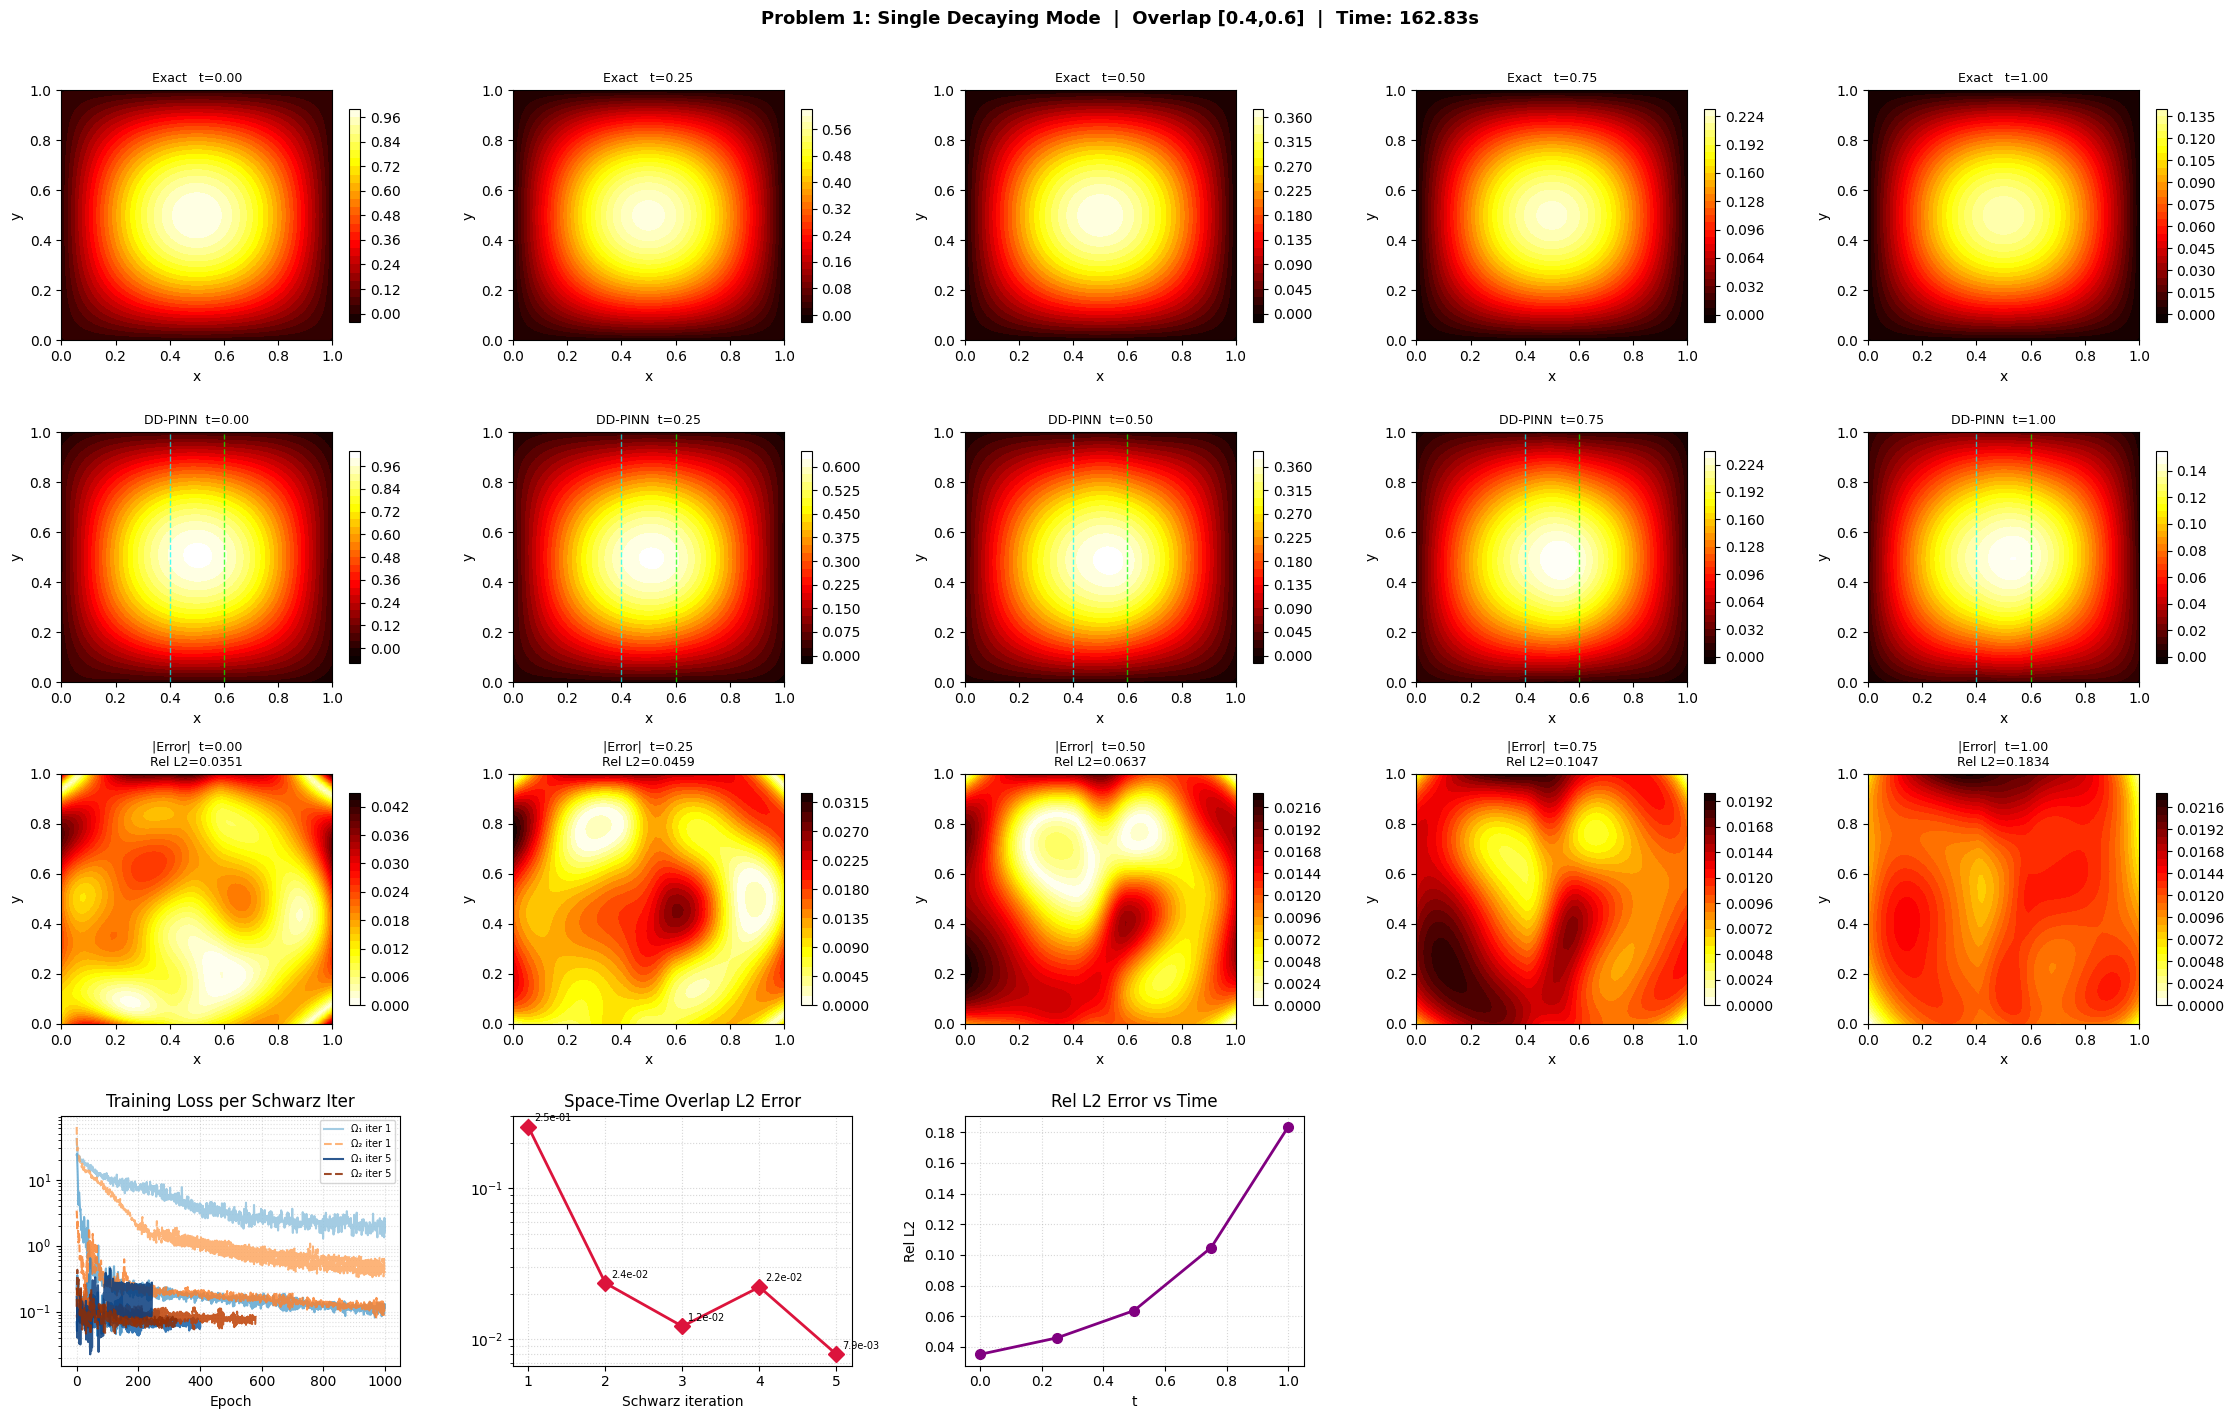

In [11]:
torch.manual_seed(42)
ALPHA1 = 0.1
T1     = 1.0
T_SNAPS1 = [0.0, 0.25, 0.5, 0.75, 1.0]
problem_name = "Problem 1: Single Decaying Mode"

ic1     = lambda xy:  (torch.sin(torch.pi*xy[:,0:1])
                       * torch.sin(torch.pi*xy[:,1:2]))

exact1  = lambda xyt: (torch.exp(-2*ALPHA1*torch.pi**2*xyt[:,2:3])
                       * torch.sin(torch.pi*xyt[:,0:1])
                       * torch.sin(torch.pi*xyt[:,1:2]))

print(f"Running {problem_name}...")
print(f"alpha={ALPHA1}, T={T1}")
print(f"Amplitude at T={T1}: "
      f"{float(torch.exp(torch.tensor(-2*ALPHA1*torch.pi**2*T1))):.4f} "
      f"(fraction of initial)")

net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_heat(
    ic1,
    alpha=ALPHA1, T=T1,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE, n_ic=N_IC,
    lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC,
    lr=LR, patience=PATIENCE
)

X1, Y1, res1, ts1 = evaluate_heat_dd(
    net1, net2, exact1, X_A, X_B, T1,
    t_snaps=T_SNAPS1, n_grid=60
)

print_heat_stats(lhist, ov_errs, i_times, elapsed,
                  EPOCHS_PER_ITER, SCHWARZ_ITERS, res1, ts1)

timing_records.append({
    'problem'       : problem_name,
    'train_time_s'  : elapsed,
    'mean_rel_l2'   : np.mean([res1[t]['rel_l2'] for t in ts1]),
    'final_rel_l2'  : res1[T1]['rel_l2'],
    'final_ov_err'  : ov_errs[-1]
})

plot_heat_dd(X1, Y1, res1, ts1, lhist, ov_errs,
              X_A, X_B, problem_name, elapsed)

## Problem 2 — Higher Spatial Mode ($\alpha=0.1$, $T=0.5$)

$$u(x,y,t) = e^{-5\alpha\pi^2 t}\sin(\pi x)\sin(2\pi y)$$

**Verification:** $u_{xx} = -\pi^2 u$, $u_{yy} = -4\pi^2 u$, so
$\alpha(u_{xx}+u_{yy}) = -5\alpha\pi^2 u = u_t$ ✓

Decays **5x faster** than Problem 1 due to higher mode. $T=0.5$ used to observe meaningful diffusion.
Interface at $x_b=0.6$: $u(0.6,y,t) = e^{-5\alpha\pi^2 t}\sin(0.6\pi)\sin(2\pi y)$ — two sine oscillations in $y$.

Running Problem 2: Higher Spatial Mode...
alpha=0.1, T=0.5

── Schwarz Iteration 1/5 ──
  Ω₁: 1000 epochs | t=27.87s | loss=1.7291e+00
  Ω₂: 1000 epochs | t=26.86s | loss=3.1120e-01
  Overlap L2 error (space-time): 1.3620e-01

── Schwarz Iteration 2/5 ──
  Ω₁: 1000 epochs | t=27.21s | loss=6.8572e-02
  Ω₂:  750 epochs | t=20.71s | loss=1.5342e-01
  Overlap L2 error (space-time): 1.3229e-02

── Schwarz Iteration 3/5 ──
  Ω₁:  444 epochs | t=12.79s | loss=9.7414e-02
  Ω₂:  570 epochs | t=15.40s | loss=1.3944e-01
  Overlap L2 error (space-time): 1.6020e-02

── Schwarz Iteration 4/5 ──
  Ω₁:  637 epochs | t=17.96s | loss=6.0630e-02
  Ω₂:  452 epochs | t=12.24s | loss=1.0418e-01
  Overlap L2 error (space-time): 1.4460e-02

── Schwarz Iteration 5/5 ──
  Ω₁:  226 epochs | t=6.35s | loss=4.6919e-02
  Ω₂:  305 epochs | t=8.29s | loss=8.5451e-02
  Overlap L2 error (space-time): 2.3959e-02

──────────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epoc

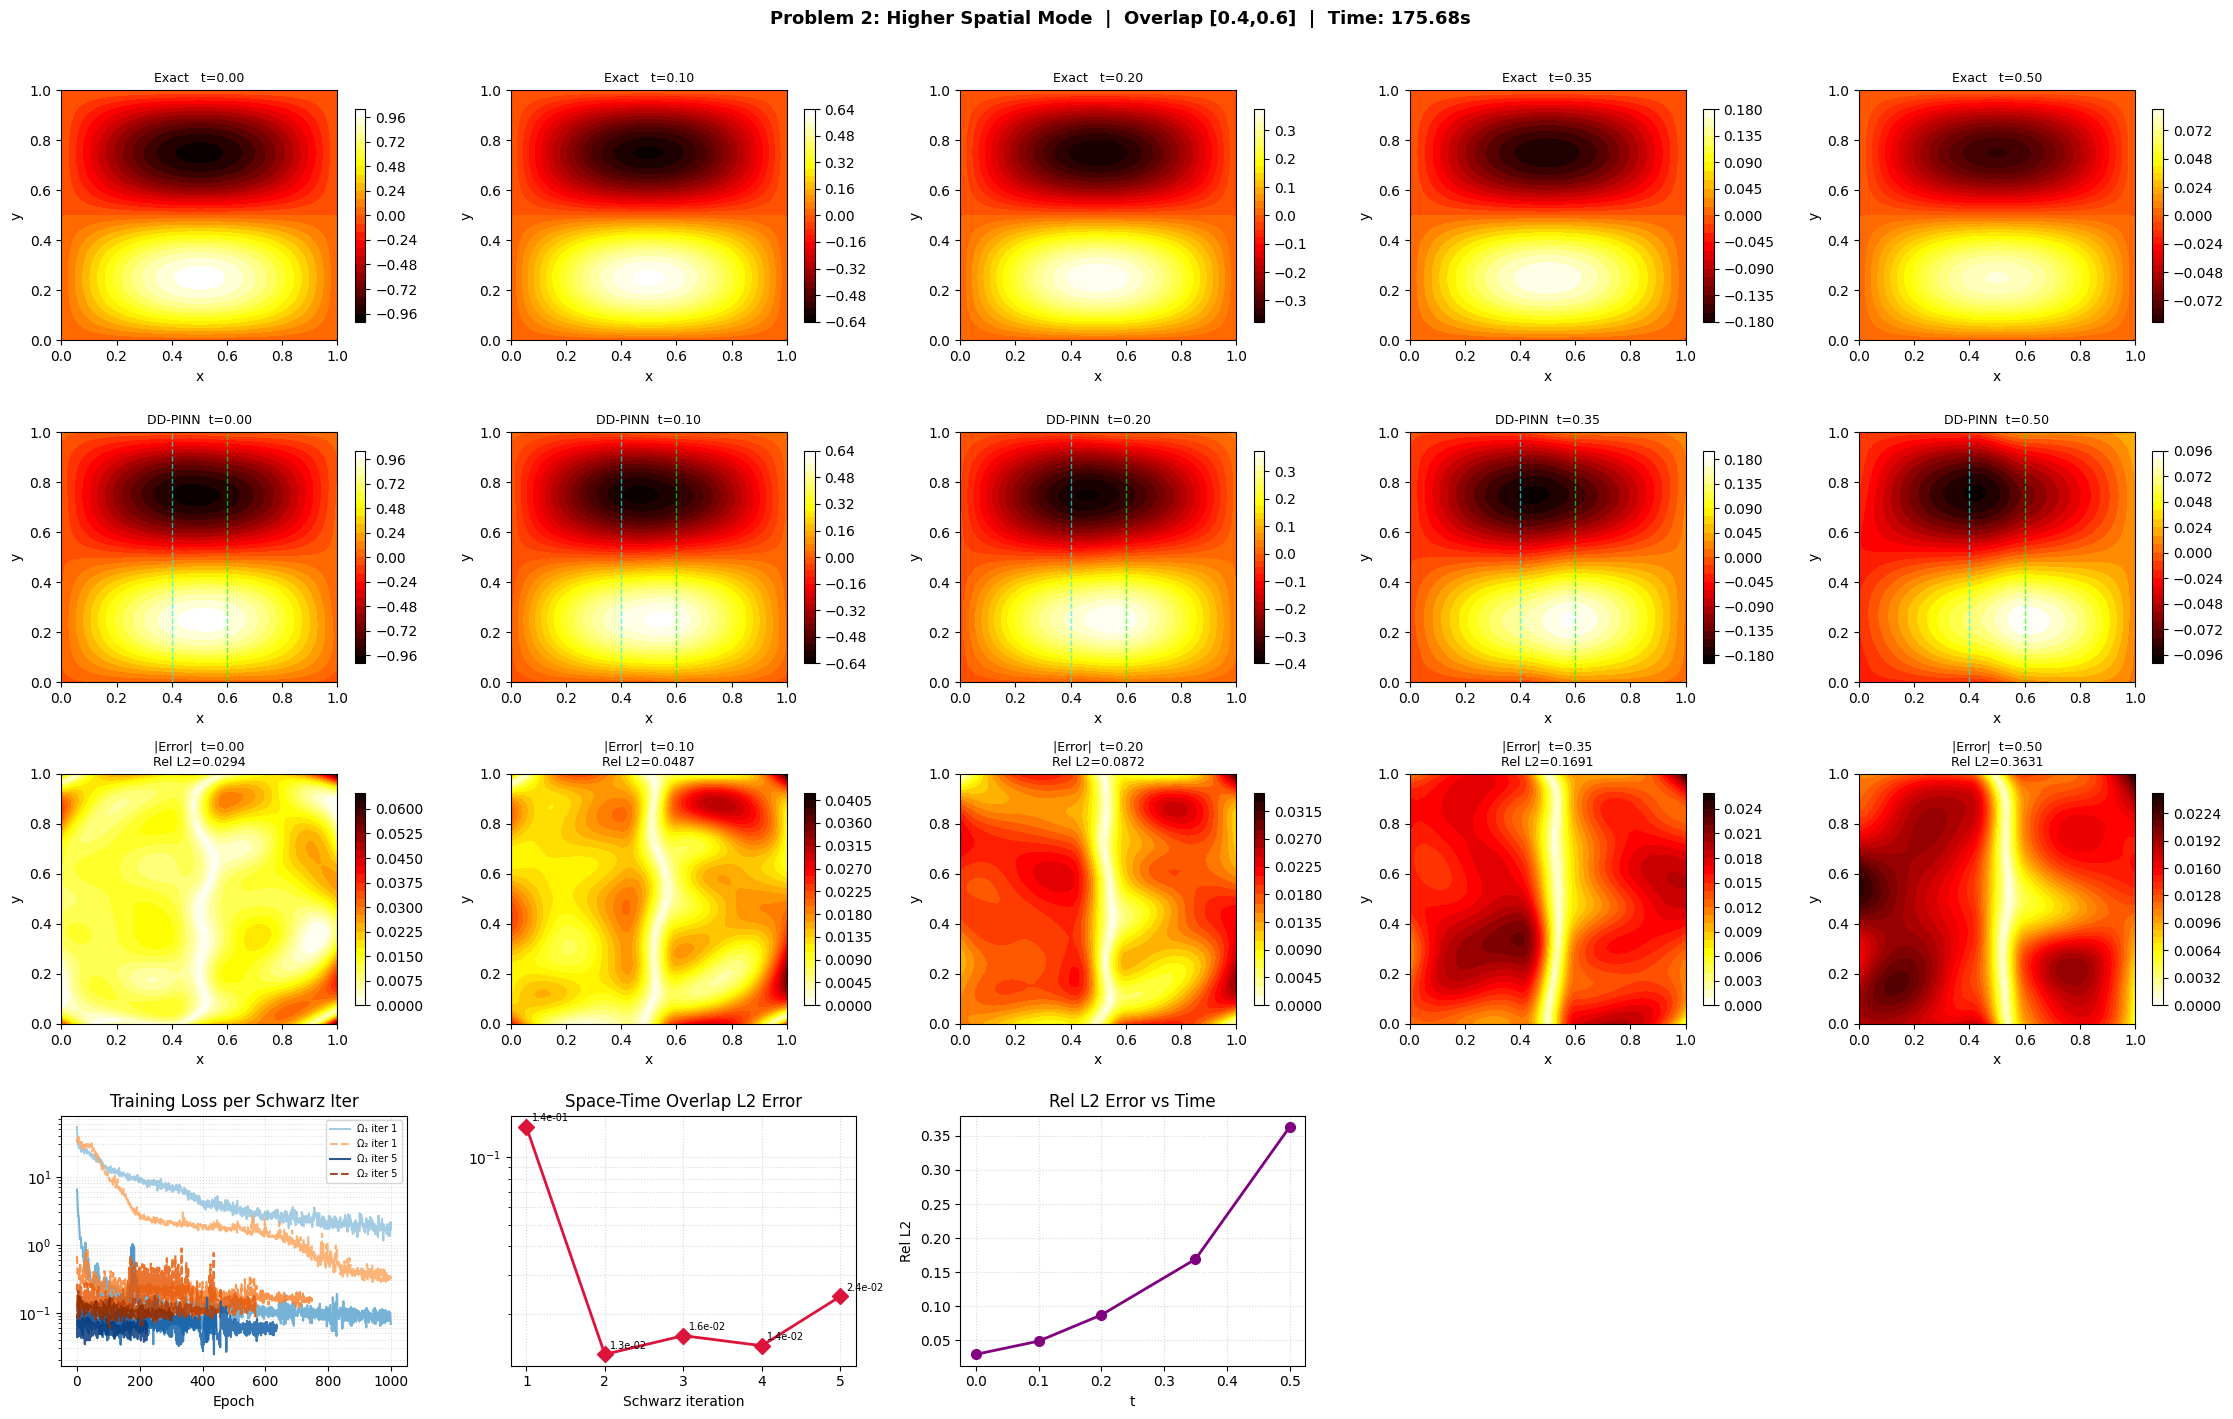

In [12]:
torch.manual_seed(42)
ALPHA2   = 0.1
T2       = 0.5
T_SNAPS2 = [0.0, 0.1, 0.2, 0.35, 0.5]
problem_name = "Problem 2: Higher Spatial Mode"

ic2    = lambda xy:  (torch.sin(torch.pi*xy[:,0:1])
                      * torch.sin(2*torch.pi*xy[:,1:2]))

exact2 = lambda xyt: (torch.exp(-5*ALPHA2*torch.pi**2*xyt[:,2:3])
                      * torch.sin(torch.pi*xyt[:,0:1])
                      * torch.sin(2*torch.pi*xyt[:,1:2]))

print(f"Running {problem_name}...")
print(f"alpha={ALPHA2}, T={T2}")

net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_heat(
    ic2,
    alpha=ALPHA2, T=T2,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE, n_ic=N_IC,
    lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC,
    lr=LR, patience=PATIENCE
)

X2, Y2, res2, ts2 = evaluate_heat_dd(
    net1, net2, exact2, X_A, X_B, T2,
    t_snaps=T_SNAPS2, n_grid=60
)

print_heat_stats(lhist, ov_errs, i_times, elapsed,
                  EPOCHS_PER_ITER, SCHWARZ_ITERS, res2, ts2)

timing_records.append({
    'problem'       : problem_name,
    'train_time_s'  : elapsed,
    'mean_rel_l2'   : np.mean([res2[t]['rel_l2'] for t in ts2]),
    'final_rel_l2'  : res2[T2]['rel_l2'],
    'final_ov_err'  : ov_errs[-1]
})

plot_heat_dd(X2, Y2, res2, ts2, lhist, ov_errs,
              X_A, X_B, problem_name, elapsed)

## Problem 3 — Two-Mode Superposition ($\alpha=0.1$, $T=0.5$)

$$u(x,y,t) = e^{-2\alpha\pi^2 t}\sin(\pi x)\sin(\pi y) + 0.5\,e^{-8\alpha\pi^2 t}\sin(2\pi x)\sin(2\pi y)$$

Both terms independently satisfy the heat equation, so their superposition does too.
The second mode ($k=2$) decays **4x faster** than the first ($k=1$), so at later times only the first mode survives.

This tests the network's ability to represent **multi-scale solutions** — the hardest problem for PINNs due to spectral bias.

Running Problem 3: Two-Mode Superposition...
alpha=0.1, T=0.5

── Schwarz Iteration 1/5 ──
  Ω₁: 1000 epochs | t=30.40s | loss=2.5786e+00
  Ω₂: 1000 epochs | t=33.13s | loss=1.5934e+00
  Overlap L2 error (space-time): 2.7146e-01

── Schwarz Iteration 2/5 ──
  Ω₁: 1000 epochs | t=28.50s | loss=3.4048e-01
  Ω₂: 1000 epochs | t=27.70s | loss=6.7430e-01
  Overlap L2 error (space-time): 4.2705e-02

── Schwarz Iteration 3/5 ──
  Ω₁: 1000 epochs | t=30.10s | loss=1.1708e-01
  Ω₂: 1000 epochs | t=53.17s | loss=1.8404e-01
  Overlap L2 error (space-time): 1.8282e-02

── Schwarz Iteration 4/5 ──
  Ω₁:  311 epochs | t=28.94s | loss=7.6847e-02
  Ω₂:  464 epochs | t=16.31s | loss=1.3131e-01
  Overlap L2 error (space-time): 1.1261e-02

── Schwarz Iteration 5/5 ──
  Ω₁:  292 epochs | t=8.27s | loss=9.0054e-02
  Ω₂:  219 epochs | t=5.88s | loss=1.1838e-01
  Overlap L2 error (space-time): 9.7973e-03

──────────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ E

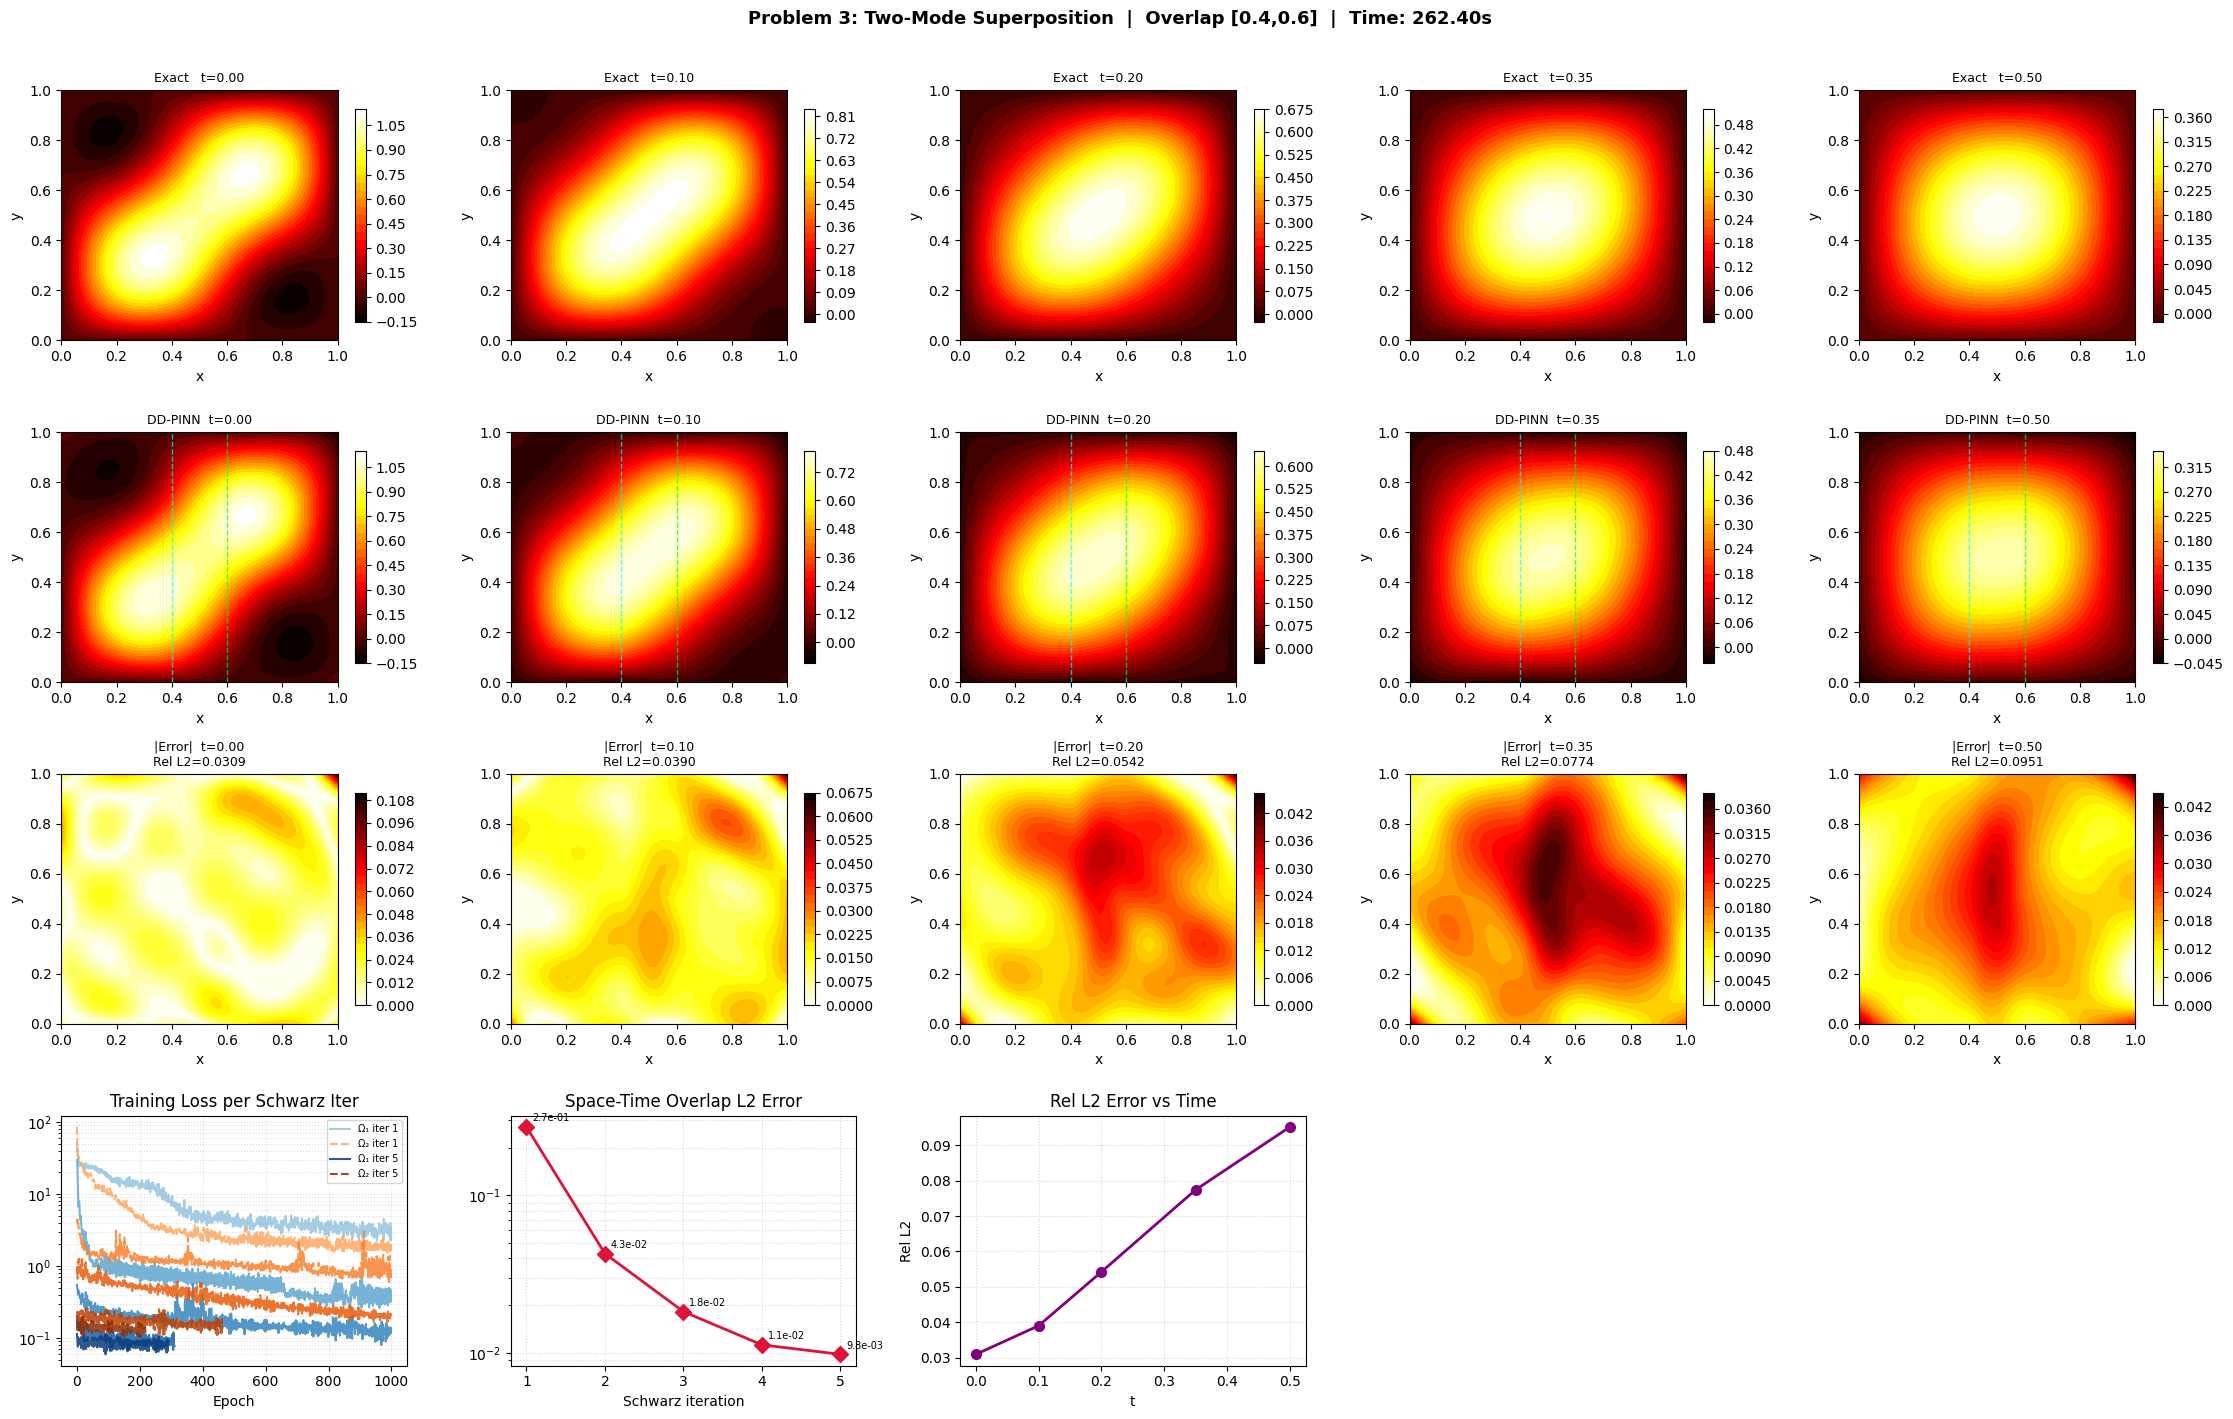

In [13]:
torch.manual_seed(42)
ALPHA3   = 0.1
T3       = 0.5
T_SNAPS3 = [0.0, 0.1, 0.2, 0.35, 0.5]
problem_name = "Problem 3: Two-Mode Superposition"

def ic3(xy):
    return (torch.sin(torch.pi*xy[:,0:1]) * torch.sin(torch.pi*xy[:,1:2])
            + 0.5*torch.sin(2*torch.pi*xy[:,0:1]) * torch.sin(2*torch.pi*xy[:,1:2]))

def exact3(xyt):
    mode1 = (torch.exp(-2*ALPHA3*torch.pi**2*xyt[:,2:3])
             * torch.sin(torch.pi*xyt[:,0:1])
             * torch.sin(torch.pi*xyt[:,1:2]))
    mode2 = (0.5 * torch.exp(-8*ALPHA3*torch.pi**2*xyt[:,2:3])
             * torch.sin(2*torch.pi*xyt[:,0:1])
             * torch.sin(2*torch.pi*xyt[:,1:2]))
    return mode1 + mode2

print(f"Running {problem_name}...")
print(f"alpha={ALPHA3}, T={T3}")

net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_heat(
    ic3,
    alpha=ALPHA3, T=T3,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE, n_ic=N_IC,
    lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC,
    lr=LR, patience=PATIENCE
)

X3, Y3, res3, ts3 = evaluate_heat_dd(
    net1, net2, exact3, X_A, X_B, T3,
    t_snaps=T_SNAPS3, n_grid=60
)

print_heat_stats(lhist, ov_errs, i_times, elapsed,
                  EPOCHS_PER_ITER, SCHWARZ_ITERS, res3, ts3)

timing_records.append({
    'problem'       : problem_name,
    'train_time_s'  : elapsed,
    'mean_rel_l2'   : np.mean([res3[t]['rel_l2'] for t in ts3]),
    'final_rel_l2'  : res3[T3]['rel_l2'],
    'final_ov_err'  : ov_errs[-1]
})

plot_heat_dd(X3, Y3, res3, ts3, lhist, ov_errs,
              X_A, X_B, problem_name, elapsed)

## Section 11 — Effect of Thermal Diffusivity $\alpha$

Higher $\alpha$ means faster heat diffusion — the solution reaches steady state sooner.
We test Problem 1 with $\alpha \in \{0.01, 0.05, 0.1, 0.5\}$ and compare final accuracy.

  alpha=0.01: mean Rel L2=1.8528e-01  overlap err=5.2893e-02
  alpha=0.05: mean Rel L2=6.4725e-02  overlap err=1.9408e-02
  alpha=0.10: mean Rel L2=1.8198e-01  overlap err=8.6612e-03
  alpha=0.50: mean Rel L2=3.0793e+02  overlap err=1.7221e-02


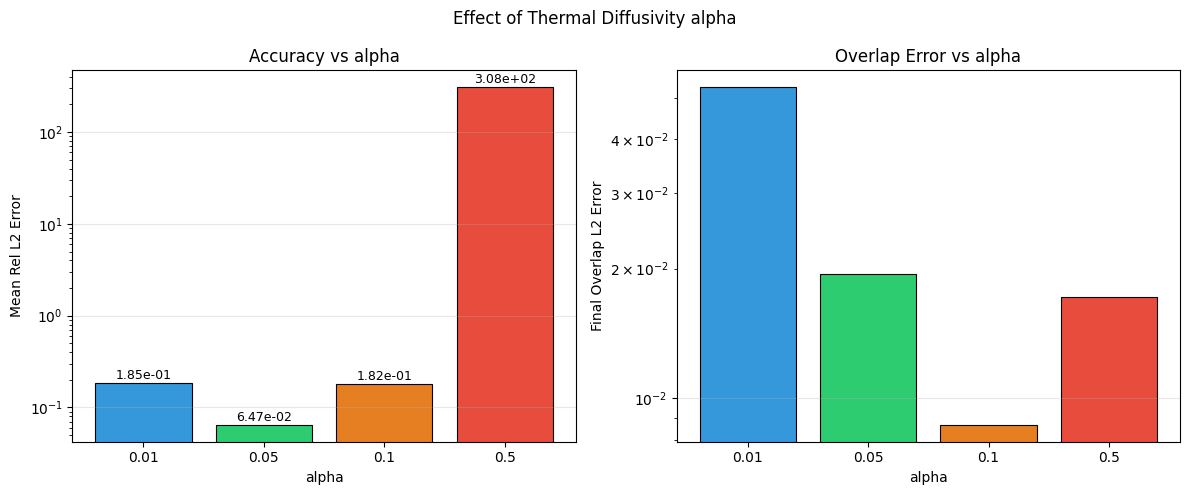

In [14]:
torch.manual_seed(42)

alphas    = [0.01, 0.05, 0.1, 0.5]
alpha_res = {}

for al in alphas:
    torch.manual_seed(42)

    def exact_al(xyt, a=al):
        return (torch.exp(-2*a*torch.pi**2*xyt[:,2:3])
                * torch.sin(torch.pi*xyt[:,0:1])
                * torch.sin(torch.pi*xyt[:,1:2]))

    n1, n2, lh, oe, el, _ = schwarz_dd_heat(
        ic1, alpha=al, T=1.0,
        x_a=X_A, x_b=X_B,
        schwarz_iters=3, epochs_per_iter=800,
        n_interior=N_INTERIOR, n_bc=N_BC,
        n_interface=N_INTERFACE, n_ic=N_IC,
        lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC,
        lr=LR, patience=PATIENCE, verbose=False
    )
    _, _, res_al, ts_al = evaluate_heat_dd(
        n1, n2, exact_al, X_A, X_B, 1.0,
        t_snaps=[0.0, 0.5, 1.0], n_grid=50
    )
    mean_err = np.mean([res_al[t]['rel_l2'] for t in ts_al])
    alpha_res[al] = {'mean_err': mean_err, 'ov_err': oe[-1], 'res': res_al}
    print(f"  alpha={al:.2f}: mean Rel L2={mean_err:.4e}  "
          f"overlap err={oe[-1]:.4e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Effect of Thermal Diffusivity alpha', fontsize=12)

colors = ['#3498db','#2ecc71','#e67e22','#e74c3c']
for c, (al, res) in zip(colors, alpha_res.items()):
    ax1.bar(str(al), res['mean_err'], color=c, edgecolor='black', linewidth=0.8)
    ax1.text(list(alpha_res.keys()).index(al), res['mean_err']*1.1,
              f'{res["mean_err"]:.2e}', ha='center', fontsize=9)
ax1.set_yscale('log'); ax1.set_xlabel('alpha')
ax1.set_ylabel('Mean Rel L2 Error'); ax1.grid(True, axis='y', alpha=0.3)
ax1.set_title('Accuracy vs alpha')

for c, (al, res) in zip(colors, alpha_res.items()):
    ax2.bar(str(al), res['ov_err'], color=c, edgecolor='black', linewidth=0.8)
ax2.set_yscale('log'); ax2.set_xlabel('alpha')
ax2.set_ylabel('Final Overlap L2 Error'); ax2.grid(True, axis='y', alpha=0.3)
ax2.set_title('Overlap Error vs alpha')

plt.tight_layout(); plt.show()

## Section 12 — Summary Table

In [15]:
print("\n" + "="*78)
print(f"  {'Problem':<42} {'Time(s)':>7} {'Mean Rel L2':>12} "
      f"{'Final Rel L2':>13} {'Ov Err':>10}")
print("="*78)
for r in timing_records:
    print(f"  {r['problem']:<42} {r['train_time_s']:>7.1f} "
          f"{r['mean_rel_l2']:>12.6f} {r['final_rel_l2']:>13.6f} "
          f"{r['final_ov_err']:>10.4e}")
print("="*78)
print(f"  Total training time: "
      f"{sum(r['train_time_s'] for r in timing_records):.1f}s")


  Problem                                    Time(s)  Mean Rel L2  Final Rel L2     Ov Err
  Problem 1: Single Decaying Mode              162.8     0.086580      0.183416 7.9423e-03
  Problem 2: Higher Spatial Mode               175.7     0.139498      0.363132 2.3959e-02
  Problem 3: Two-Mode Superposition            262.4     0.059352      0.095143 9.7973e-03
  Total training time: 600.9s
